# Deriving Topics from Resident Evil Steam Reviews

- Loads Steam reviews for RE2 Remake and RE3 Remake and fits a KeyNMF topic model (K=30) to find common review themes
- Detects mentions of other Resident Evil titles within reviews to see how often reviewers reference other games in the franchise
- Uses gpt-oss-120b to name and describe each topic, grounded in that topic's real RE2r/RE3r prevalence split to avoid cross-game mislabeling
- Computes per-review and per-game topic scores, then visualizes topic prevalence, differences between games, sentiment, and mentions over time
- Re-derives the specific numbers cited in the write-up directly from the saved data, for verification

In [31]:
from datetime import datetime
from turftopic import KeyNMF
import pandas as pd
from pathlib import Path
from sentence_transformers import SentenceTransformer
import numpy as np
import re
from rapidfuzz import fuzz
from gensim.models.phrases import Phrases, Phraser
from sklearn.feature_extraction.text import CountVectorizer
import os
from dotenv import load_dotenv
import openai
from turftopic.analyzers import OpenAIAnalyzer
from statsmodels.stats.multitest import multipletests
import plotly.express as px
import matplotlib.pyplot as plt
import types
from matplotlib.patches import Patch

## Topic Modeling with KeyNMF (pooled RE2r/RE3r)

In [3]:
encoder = SentenceTransformer("paraphrase-mpnet-base-v2")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

In [ ]:
csv_paths = {
    "re2r": Path("../raw_reviews/resident_evil_2_remake.csv"),
    "re3r": Path("../raw_reviews/resident_evil_3_remake.csv"),
}
text_column = "review"
date_column = "date_created"

dfs = []
for game, path in csv_paths.items():
    game_df = pd.read_csv(path)
    game_df["game"] = game
    dfs.append(game_df)
df = pd.concat(dfs, ignore_index=True)
df = df.dropna(subset=[text_column])

docs = df[text_column].astype(str).tolist()
game_labels = df["game"].tolist()  # keep alongside docs/embeddings for per-game breakdowns later
hover_text = [f"[{g}] {doc[:150]}" for g, doc in zip(game_labels, docs)]  # shown when hovering a point in plot_clusters_datamapplot

# Cache embeddings to disk
# Delete the .npy file (or change name) if raw_reviews/*.csv changes.
embeddings_cache = Path("../results/embeddings_re2r_re3r.npy")
if embeddings_cache.exists():
    embeddings = np.load(embeddings_cache)
    assert embeddings.shape[0] == len(docs), "cached embeddings don't match current docs — delete the cache and re-encode"
else:
    embeddings = encoder.encode(docs, show_progress_bar=True)
    np.save(embeddings_cache, embeddings)

## Mentions of other games (TO BE DELETED?)

In [7]:
# Heuristic keyword/regex detector (not entity recognition,
# but more precise and reportable than topic keywords)
TITLE_PATTERNS = {
    "re1": r"\bre\s?1r?\b|\bresident evil 1\b",
    "re0": r"\bre\s?0\b|\bresident evil 0\b|\bre zero\b",
    "re2": r"\bre\s?2r?\b|\bresident evil 2\b",
    "re3": r"\bre\s?3r?\b|\bresident evil 3\b|\bnemesis\b",
    "re4": r"\bre\s?4r?\b|\bresident evil 4\b",
    "re5": r"\bre\s?5\b|\bresident evil 5\b",
    "re6": r"\bre\s?6\b|\bresident evil 6\b",
    "re7": r"\bre\s?7\b|\bresident evil 7\b|\bbiohazard\b",
    "village": r"\bre\s?8\b|\bresident evil village\b|\bvillage\b",
    "revelations": r"\brevelations\b",
    "requiem": r"\brequiem\b",
    # "Raccoon City" is the games setting (both RE2 and RE)
    # so only "operation raccoon city" actually refers to
    # the separate 2012 spin-off
    "raccoon_city": r"\boperation raccoon city\b",
    "code_veronica": r"\bcode veronica\b|\bveronica\b",
}

SELF_TITLE = {"re2r": "re2", "re3r": "re3"}

# Fuzzy backstop for misspellings, split into two parts
FUZZY_THRESHOLD = 85
NUMBER_TO_TITLE = {"0": "re0", "zero": "re0", "1": "re1", "2": "re2", "3": "re3",
                    "4": "re4", "5": "re5", "6": "re6", "7": "re7", "village": "village"}

# Standalone unique words/phrases that are safe to fuzzy-match directly
FUZZY_PHRASES = {
    "re7": ["biohazard"],
    "re3": ["nemesis"],
    "revelations": ["revelations"],
    "requiem": ["requiem"],
    "raccoon_city": ["operation raccoon city"],  # not "raccoon city"
}


def fuzzy_contains(text_l: str, phrase: str) -> bool:
    words = text_l.split()
    n = len(phrase.split())
    return any(
        fuzz.ratio(" ".join(words[i : i + n]), phrase) >= FUZZY_THRESHOLD
        for i in range(len(words) - n + 1)
    )


def fuzzy_resident_evil_number(text_l: str) -> set:
    words = text_l.split()
    hits = set()
    for i in range(len(words) - 1):
        window = f"{words[i]} {words[i + 1]}"
        if fuzz.ratio(window, "resident evil") >= FUZZY_THRESHOLD and i + 2 < len(words):
            nxt = words[i + 2].strip(".,!?")
            if nxt in NUMBER_TO_TITLE:
                hits.add(NUMBER_TO_TITLE[nxt])
    return hits

REMAKEABLE_TITLES = {"re1", "re2", "re3", "re4"}
REMAKE_SIGNAL = r"remake|re-make|remaster(ed)?|\bre[1-4]r\b|\b(2002|2019|2020|2023)\b"
ORIGINAL_SIGNAL = r"original|\bog\b|classic|ps1|psx|ps2|playstation ?1|\b(1996|1998|1999|2005)\b"
CONTEXT_WINDOW = 40  # characters on each side of the matched title mention

def qualify_remake_mentions(text_l: str, hits: set) -> set:
    qualified = set()
    for name in hits:
        if name not in REMAKEABLE_TITLES:
            qualified.add(name)
            continue
        matches = list(re.finditer(TITLE_PATTERNS[name], text_l))
        if not matches:
            qualified.add(f"{name}_unspecified")
            continue
        for m in matches:
            start = max(0, m.start() - CONTEXT_WINDOW)
            end = min(len(text_l), m.end() + CONTEXT_WINDOW)
            window = text_l[start:end]
            has_remake = bool(re.search(REMAKE_SIGNAL, window))
            has_original = bool(re.search(ORIGINAL_SIGNAL, window))
            if has_remake:
                qualified.add(f"{name}_remake")
            if has_original:
                qualified.add(f"{name}_original")
            if not has_remake and not has_original:
                qualified.add(f"{name}_unspecified")
    return qualified

def find_other_title_mentions(text: str, game: str) -> list[str]:
    text_l = text.lower()
    self_key = SELF_TITLE.get(game)

    hits = {
        name
        for name, pattern in TITLE_PATTERNS.items()
        if name != self_key and re.search(pattern, text_l)
    }
    hits |= fuzzy_resident_evil_number(text_l) - {self_key}
    hits |= {
        name
        for name, phrases in FUZZY_PHRASES.items()
        if name != self_key and any(fuzzy_contains(text_l, p) for p in phrases)
    }
    hits = qualify_remake_mentions(text_l, hits)
    return sorted(hits)

df["other_title_mentions"] = [
    find_other_title_mentions(text, game)
    for text, game in zip(df["review"], df["game"])
]
df["mentions_other_title"] = df["other_title_mentions"].apply(len) > 0

pct_mentioning_other_title = df.groupby("game")["mentions_other_title"].mean() * 100
print("% of reviews referencing another RE title:")
print(pct_mentioning_other_title)
print()

mention_counts = (
    df.explode("other_title_mentions")
    .dropna(subset=["other_title_mentions"])
    .groupby(["game", "other_title_mentions"])
    .size()
    .unstack(fill_value=0)
)
mention_counts

% of reviews referencing another RE title:
game
re2r     7.998203
re3r    25.391316
Name: mentions_other_title, dtype: float64



other_title_mentions,code_veronica,raccoon_city,re0,re1_original,re1_remake,re1_unspecified,re2_original,re2_remake,re2_unspecified,re3_original,...,re3_unspecified,re4_original,re4_remake,re4_unspecified,re5,re6,re7,requiem,revelations,village
game,,,,,,,,,,,,,,,,,,,,,
re2r,291,23,191,116,426,340,0,0,0,145,...,1141,191,615,1321,300,295,1300,325,150,313
re3r,223,36,83,70,196,237,907,6841,4953,0,...,0,85,651,567,225,345,490,141,86,285


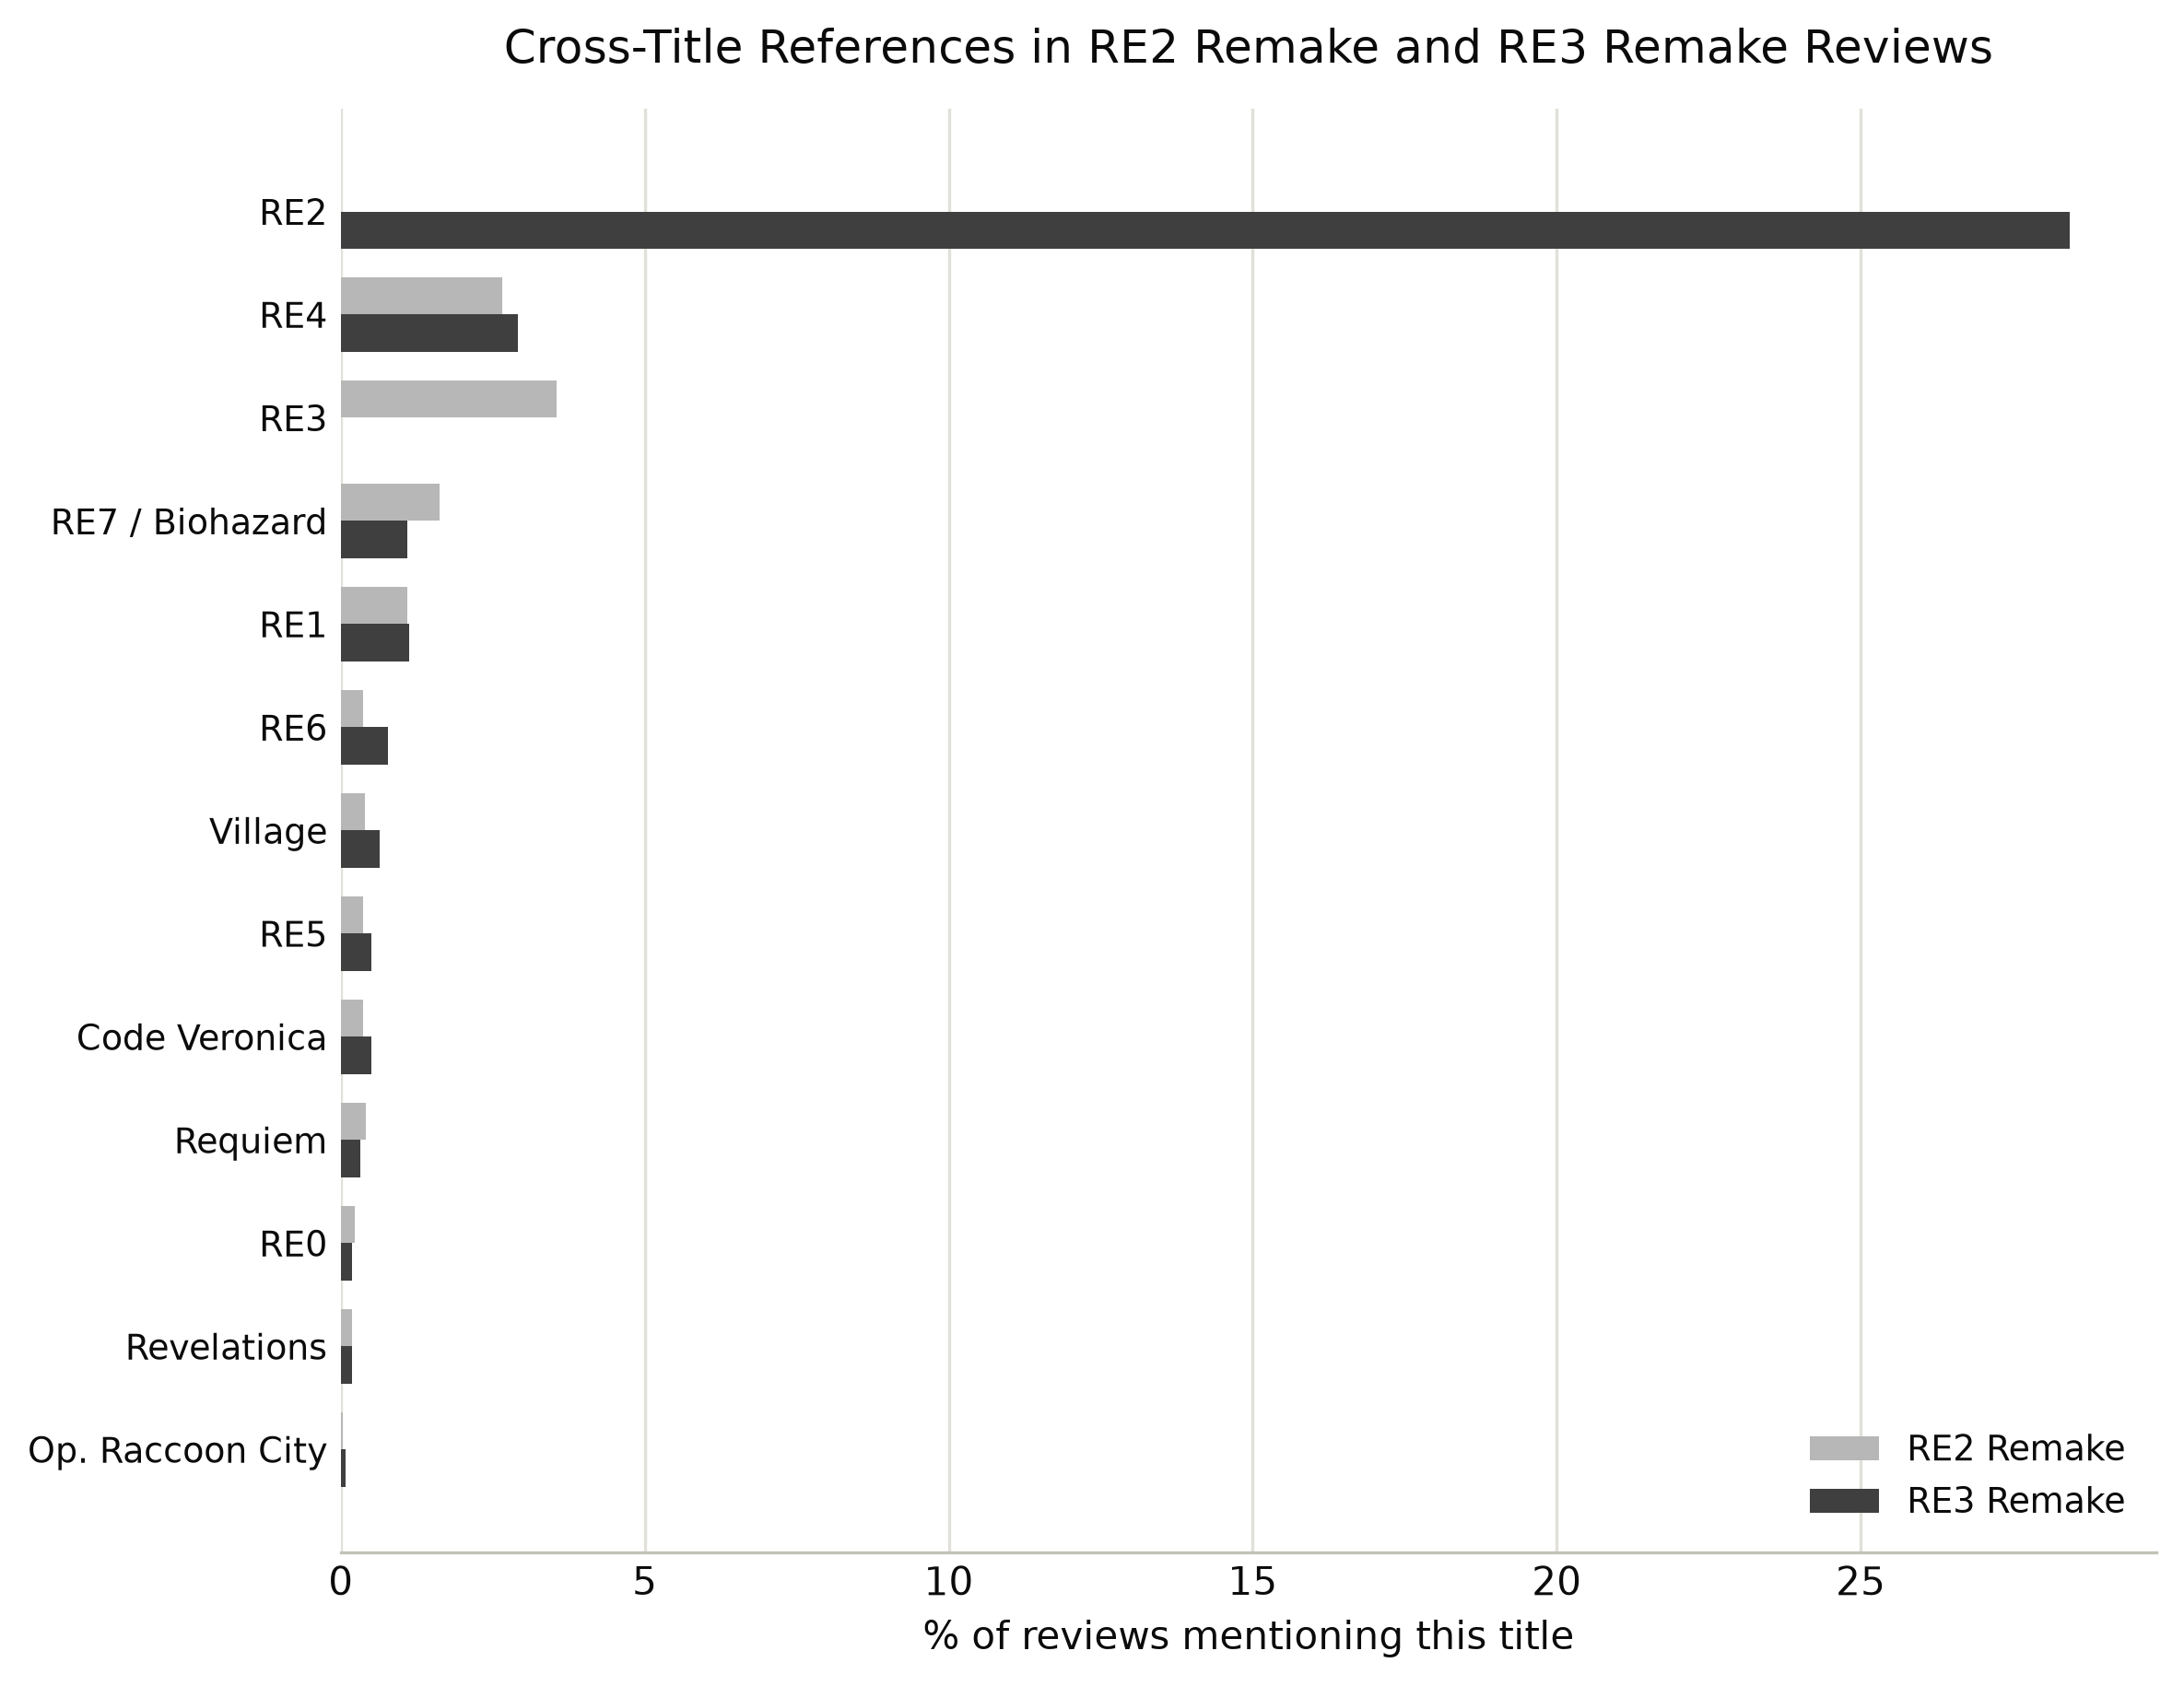

In [24]:
VIZ_DIR = Path("../results/vizualizations")
VIZ_DIR.mkdir(parents=True, exist_ok=True)

COLOR_RE2R = "#B7B7B7"
COLOR_RE3R = "#3F3F3F"
INK_PRIMARY = "#0b0b0b"
COLOR_NEUTRAL = "#e8e8e4"
GRIDLINE = "#e1e0d9"
BASELINE = "#c3c2b7"

TITLE_LABELS = {
    "re0": "RE0", "re1": "RE1", "re2": "RE2", "re3": "RE3", "re4": "RE4",
    "re5": "RE5", "re6": "RE6", "re7": "RE7 / Biohazard", "village": "Village",
    "revelations": "Revelations", "requiem": "Requiem", "raccoon_city": "Op. Raccoon City",
    "code_veronica": "Code Veronica",
}

def base_title(col):
    for suffix in ("_remake", "_original", "_unspecified"):
        if col.endswith(suffix):
            return col[: -len(suffix)]
    return col

mention_counts_by_title = mention_counts.T.groupby(base_title).sum().T

n_reviews = df.groupby("game").size()
pct = mention_counts_by_title.div(n_reviews, axis=0) * 100
plot_df = pct.T.rename(index=TITLE_LABELS)
plot_df["total"] = plot_df["re2r"] + plot_df["re3r"]
plot_df = plot_df.sort_values("total", ascending=True)

fig, ax = plt.subplots(figsize=(8, 0.4 * len(plot_df) + 1), dpi=300)
y = np.arange(len(plot_df))
bar_height = 0.36

ax.barh(y + bar_height / 2, plot_df["re2r"], height=bar_height, color=COLOR_RE2R, label="RE2 Remake", zorder=3)
ax.barh(y - bar_height / 2, plot_df["re3r"], height=bar_height, color=COLOR_RE3R, label="RE3 Remake", zorder=3)

ax.set_yticks(y)
ax.set_yticklabels(plot_df.index, fontsize=9, color=INK_PRIMARY)

ax.set_xlabel("% of reviews mentioning this title", color=INK_PRIMARY, fontsize=10)
ax.set_title("Cross-Title References in RE2 Remake and RE3 Remake Reviews", color=INK_PRIMARY, fontsize=12, pad=12)

ax.xaxis.grid(True, color=GRIDLINE, linewidth=0.8, zorder=0)
ax.set_axisbelow(True)
for spine in ["top", "right", "left"]:
    ax.spines[spine].set_visible(False)
ax.spines["bottom"].set_color(BASELINE)
ax.tick_params(axis="both", colors=INK_PRIMARY, length=0)

legend = ax.legend(loc="lower right", frameon=False, fontsize=9)
for text in legend.get_texts():
    text.set_color(INK_PRIMARY)

plt.tight_layout()
plt.savefig(VIZ_DIR / "cross_title_mentions.png", bbox_inches="tight")
plt.show()

## Sentiment of Games

In [ ]:
sentiment_by_game = df.groupby("game")["sentiment"].agg(["mean", "count"]).rename(
    columns={"mean": "pct_positive", "count": "n_reviews"}
)
sentiment_by_game["pct_positive"] *= 100
sentiment_by_game

,pct_positive,n_reviews
game,,
re2r,96.855888,80118
re3r,82.117025,44657


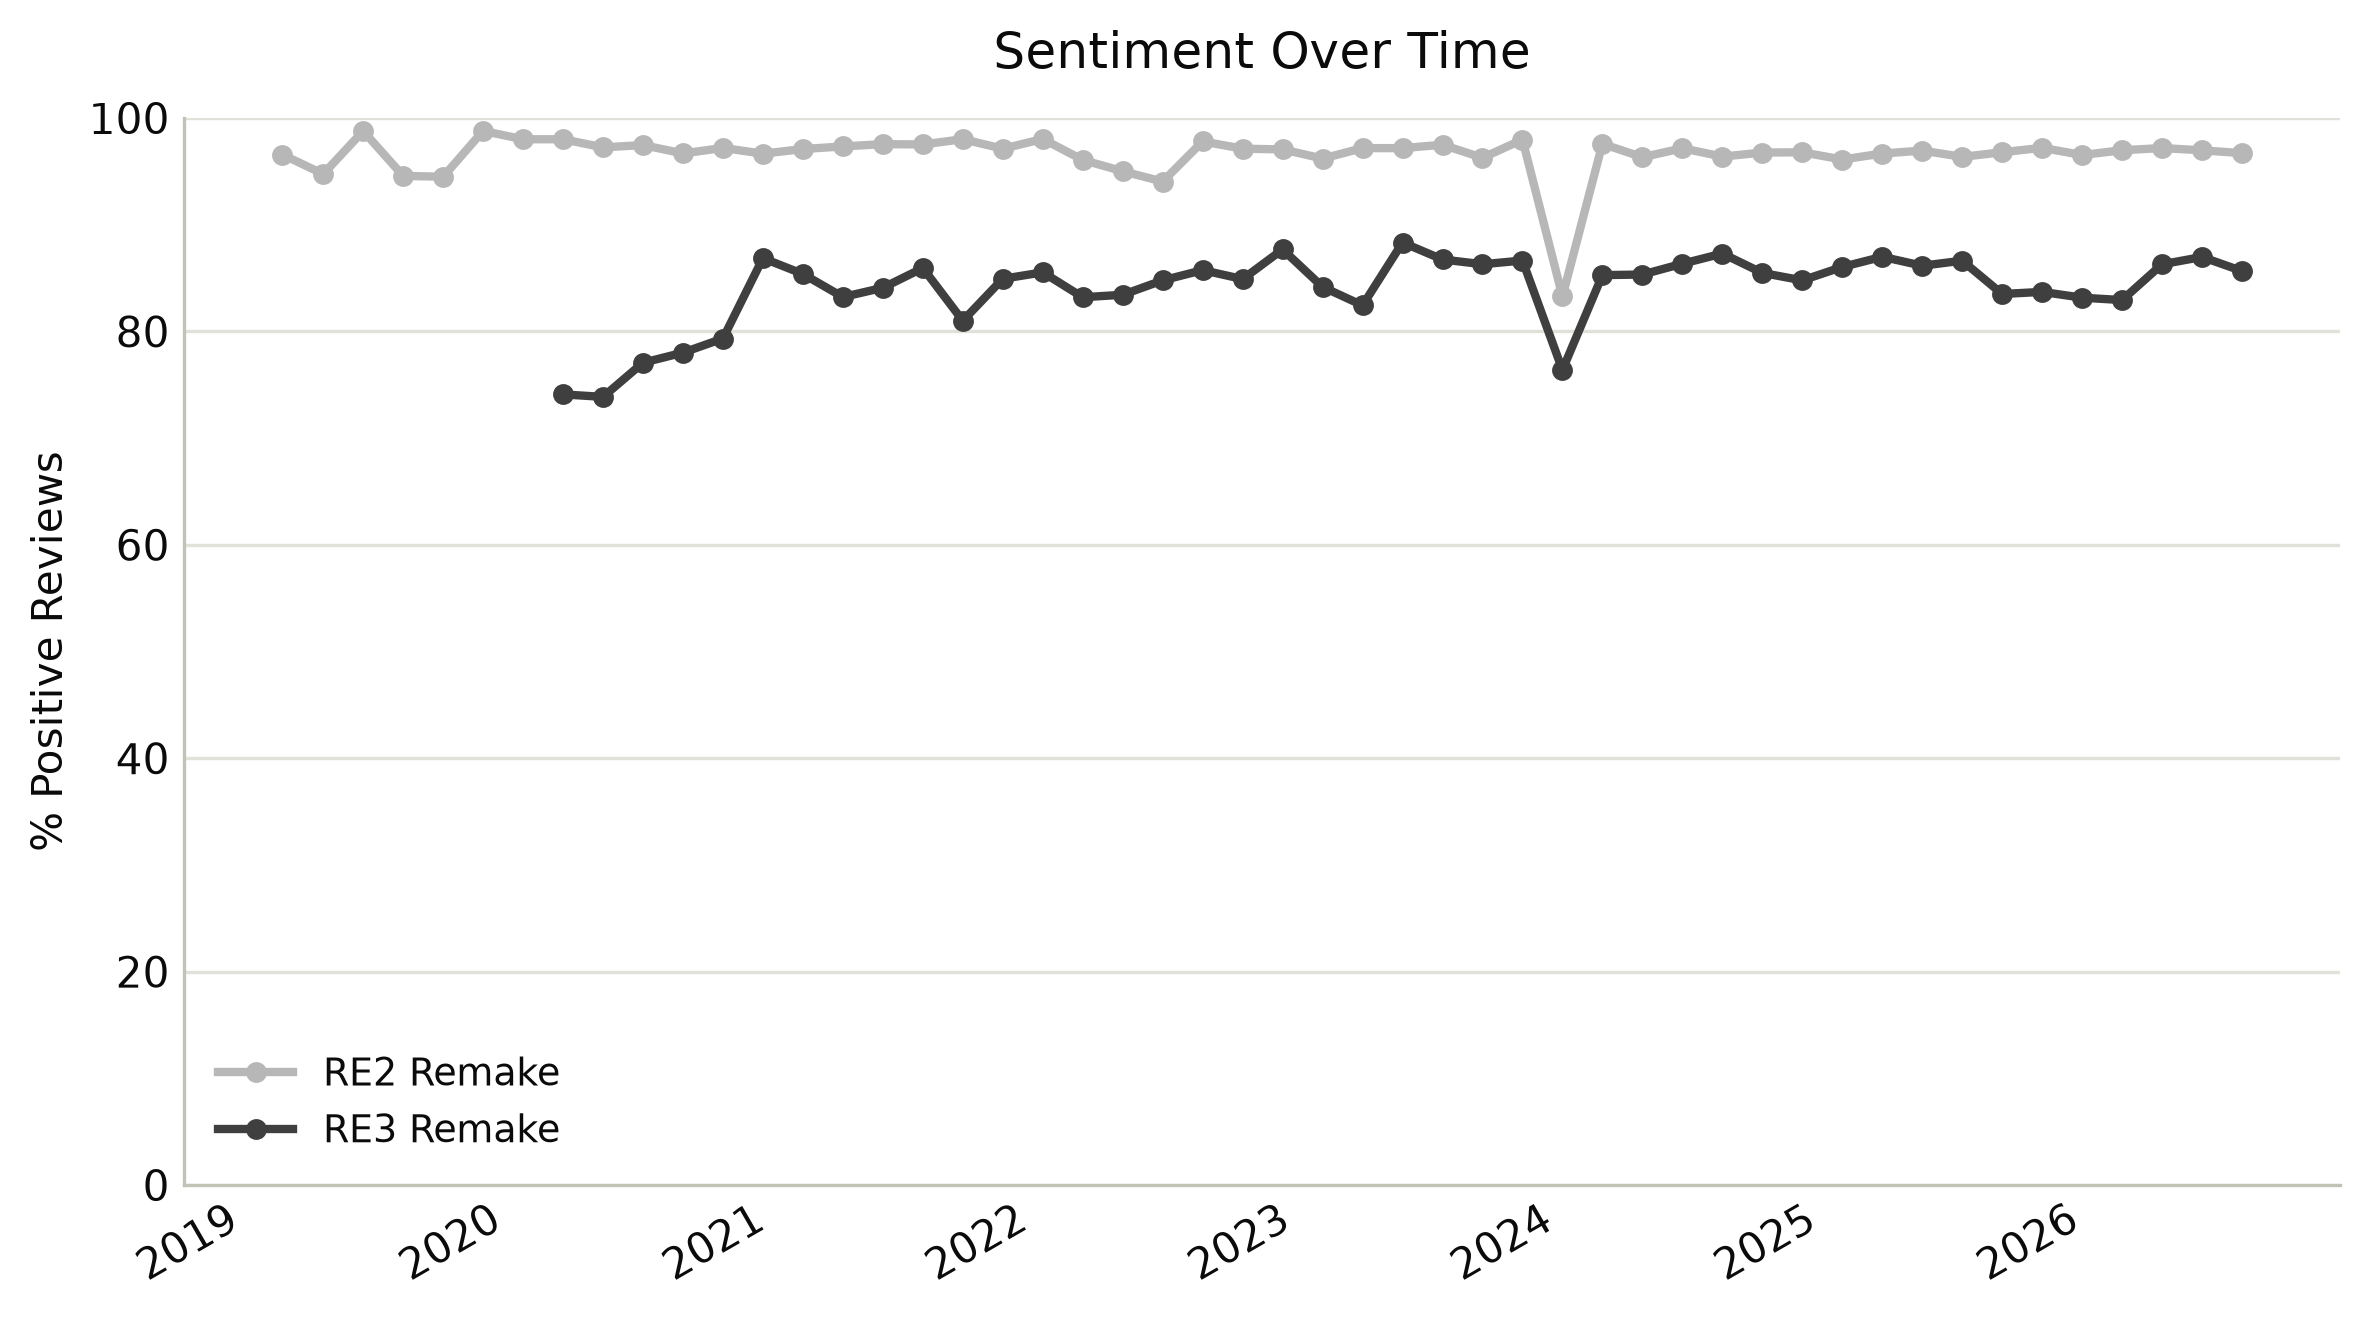

In [ ]:
VIZ_DIR = Path("../results/vizualizations")
VIZ_DIR.mkdir(parents=True, exist_ok=True)

COLOR_RE2R = "#B7B7B7"
COLOR_RE3R = "#3F3F3F"
INK_PRIMARY = "#0b0b0b"
GRIDLINE = "#e1e0d9"
BASELINE = "#c3c2b7"

TIME_BINS = 50
tmp = df.copy()
tmp["date"] = pd.to_datetime(tmp["date_created"])
tmp["time_bin"] = pd.cut(tmp["date"], bins=TIME_BINS)
sentiment_over_time = (
    tmp.groupby(["game", "time_bin"], observed=True)["sentiment"].mean().mul(100).reset_index()
)
sentiment_over_time["time_bin_mid"] = sentiment_over_time["time_bin"].apply(lambda i: i.mid)

fig, ax = plt.subplots(figsize=(8, 4.5), dpi=300)
for g, color, label in [("re2r", COLOR_RE2R, "RE2 Remake"), ("re3r", COLOR_RE3R, "RE3 Remake")]:
    sub = sentiment_over_time[sentiment_over_time["game"] == g].sort_values("time_bin_mid")
    ax.plot(sub["time_bin_mid"], sub["sentiment"], color=color, marker="o", markersize=4, linewidth=2, label=label, zorder=3)

ax.set_ylabel("% Positive Reviews", color=INK_PRIMARY, fontsize=10)
ax.set_title("Sentiment Over Time", color=INK_PRIMARY, fontsize=12, pad=12)
ax.set_ylim(0, 100)

ax.yaxis.grid(True, color=GRIDLINE, linewidth=0.8, zorder=0)
ax.set_axisbelow(True)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
ax.spines["left"].set_color(BASELINE)
ax.spines["bottom"].set_color(BASELINE)
ax.tick_params(axis="both", colors=INK_PRIMARY, length=0)
fig.autofmt_xdate(rotation=30, ha="right")

legend = ax.legend(loc="lower left", frameon=False, fontsize=9)
for text in legend.get_texts():
    text.set_color(INK_PRIMARY)

plt.tight_layout()
plt.savefig(VIZ_DIR / "sentiment_over_time.png", bbox_inches="tight")
plt.show()


In [11]:
# find reviewers who reviewed both games, and pair up their reviews for
# qualitative reading, "did the same person love one remake and hate the other?"
author_game_counts = df.groupby("author_number")["game"].nunique()
both_games_authors = author_game_counts[author_game_counts > 1].index

re2r_by_author = df[(df["game"] == "re2r") & (df["author_number"].isin(both_games_authors))]
re3r_by_author = df[(df["game"] == "re3r") & (df["author_number"].isin(both_games_authors))]

paired_reviews = re2r_by_author.merge(
    re3r_by_author,
    on="author_number",
    suffixes=("_re2r", "_re3r"),
)[[
    "author_number",
    "review_re2r", "sentiment_re2r", "date_created_re2r",
    "review_re3r", "sentiment_re3r", "date_created_re3r",
]]

paired_reviews["sentiment_flipped"] = paired_reviews["sentiment_re2r"] != paired_reviews["sentiment_re3r"]
pos_to_neg = ((paired_reviews["sentiment_re2r"] == 1) & (paired_reviews["sentiment_re3r"] == 0)).sum()
neg_to_pos = ((paired_reviews["sentiment_re2r"] == 0) & (paired_reviews["sentiment_re3r"] == 1)).sum()
print(
    f"{len(paired_reviews)} reviewers reviewed both games "
    f"({paired_reviews['sentiment_flipped'].sum()} with flipped sentiment: "
    f"{pos_to_neg} liked RE2r but disliked RE3r, "
    f"{neg_to_pos} disliked RE2r but liked RE3r)."
)

paired_reviews.sort_values("sentiment_flipped", ascending=False)

19060 reviewers reviewed both games (2587 with flipped sentiment: 2427 liked RE2r but disliked RE3r, 160 disliked RE2r but liked RE3r).


,author_number,review_re2r,sentiment_re2r,date_created_re2r,review_re3r,sentiment_re3r,date_created_re3r,sentiment_flipped
10074,author_036886,Most of the praise I give for this game goes t...,1,2023-01-01,My overall thoughts about this game are meh. T...,0,2023-01-11,True
11941,author_044174,Love it!,1,2021-11-24,The first thing I have to explain here is that...,0,2022-04-19,True
11935,author_044149,"""Resident Evil 2"" has everything we expect fro...",1,2021-11-25,A sweet that tasted bitter after years! \n \nR...,0,2024-05-14,True
16329,author_074828,That guy's a maniac! WHY'DHEBITEME?\n\nThat ma...,1,2019-11-28,Disappointing in almost every way. Music was O...,0,2020-04-07,True
3041,author_011515,"My favourite in the series so far, Leon, Clair...",1,2026-02-21,"I shell of its former self, almost unreconizab...",0,2026-02-21,True
...,...,...,...,...,...,...,...,...
6702,author_024406,It's not an easy game. Not an easy work to aim...,1,2024-06-10,"It's a good game however, as ppl said and it's...",1,2026-03-25,False
6703,author_024407,"""Damn... Shoulda packed my parka."" \n \n10/10 ...",1,2024-06-10,it's fun but like only 2 minutes long,1,2025-08-19,False
6704,author_024412,Great game one of the best Resident Evil Games...,1,2024-06-09,Pretty good but I prefer all other titles RE4 ...,1,2024-06-09,False
6705,author_024420,the kiss>>>,1,2024-06-09,---{ Graphics }---\n☐ You forget what reality ...,1,2024-04-28,False


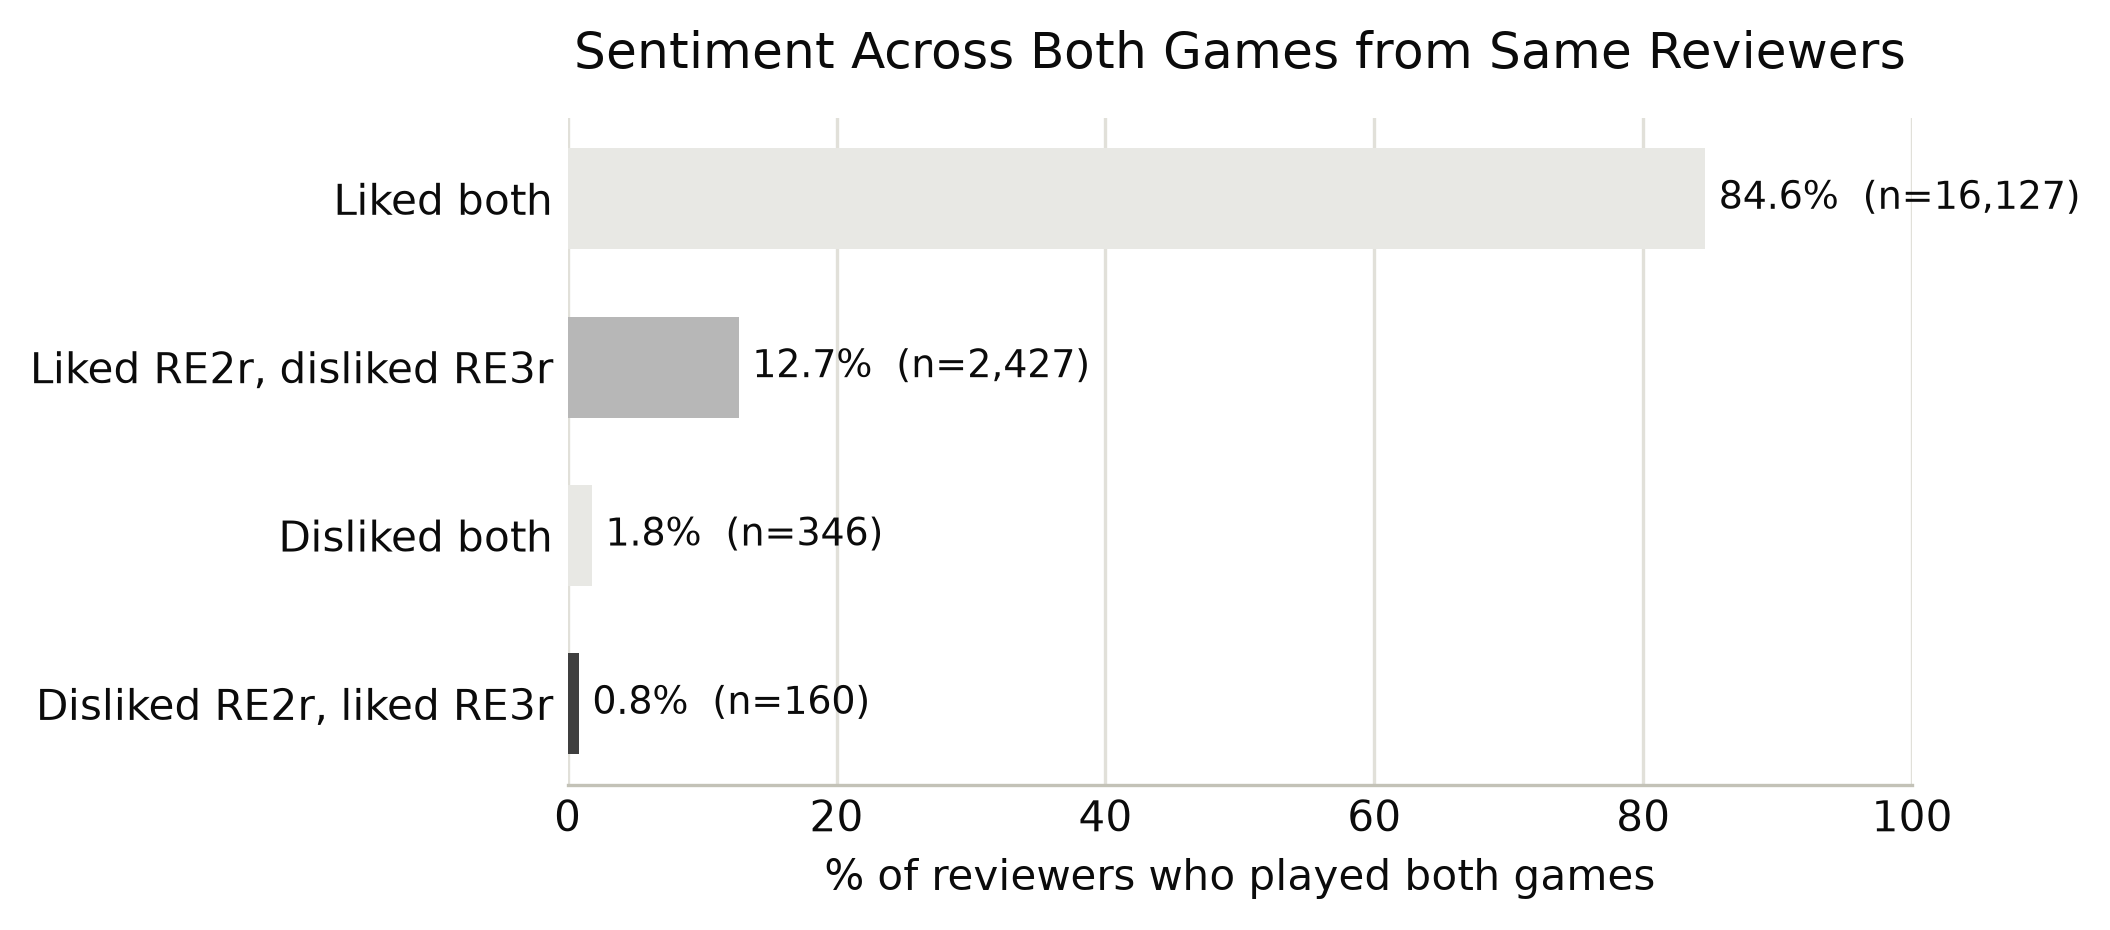

In [ ]:
total_paired = len(paired_reviews)
both_positive = ((paired_reviews["sentiment_re2r"] == 1) & (paired_reviews["sentiment_re3r"] == 1)).sum()
both_negative = ((paired_reviews["sentiment_re2r"] == 0) & (paired_reviews["sentiment_re3r"] == 0)).sum()

categories = [
    ("Liked both", both_positive, COLOR_NEUTRAL),
    ("Liked RE2r, disliked RE3r", pos_to_neg, COLOR_RE2R),
    ("Disliked RE2r, liked RE3r", neg_to_pos, COLOR_RE3R),
    ("Disliked both", both_negative, COLOR_NEUTRAL),
]
categories.sort(key=lambda c: c[1], reverse=True)
labels = [c[0] for c in categories]
values = [c[1] / total_paired * 100 for c in categories]
colors = [c[2] for c in categories]

fig, ax = plt.subplots(figsize=(7, 3.2), dpi=300)
y = np.arange(len(categories))
ax.barh(y, values, height=0.6, color=colors, zorder=3)

for yi, v, n in zip(y, values, [c[1] for c in categories]):
    ax.text(v + 1, yi, f"{v:.1f}%  (n={n:,})", va="center", fontsize=9, color=INK_PRIMARY)

ax.set_yticks(y)
ax.set_yticklabels(labels, fontsize=10, color=INK_PRIMARY)
ax.invert_yaxis()
ax.set_xlim(0, 100)
ax.set_xlabel("% of reviewers who played both games", color=INK_PRIMARY, fontsize=10)
ax.set_title("Sentiment Across Both Games from Same Reviewers", color=INK_PRIMARY, fontsize=12, pad=12)

ax.xaxis.grid(True, color=GRIDLINE, linewidth=0.8, zorder=0)
ax.set_axisbelow(True)
for spine in ["top", "right", "left"]:
    ax.spines[spine].set_visible(False)
ax.spines["bottom"].set_color(BASELINE)
ax.tick_params(axis="both", colors=INK_PRIMARY, length=0)

plt.tight_layout()
plt.savefig(VIZ_DIR / "sentiment_flip_breakdown.png", bbox_inches="tight")
plt.show()

## Topic Count Justification

In [ ]:
# vectorizer overrides KeyNMF's default, instead we tokenize with a plain 
# \w+ regex before handing token lists to Phrases — \w matches digits and 
# Unicode letters, so "re2r"/"re3r"/"re1"..."re8" all survive. Single 
# characters are still kept (no min-length filter) so "mr"+"x" can still 
# combine into mr_x but the final CountVectorizer step still drops leftover 
# unmerged 1-char tokens

TOKEN_RE = re.compile(r"\w+")


def tokenize(text: str) -> list[str]:
    return TOKEN_RE.findall(text.lower())


tokenized_docs = [tokenize(doc) for doc in docs]
phrases = Phrases(tokenized_docs, min_count=10, threshold=10)
phraser = Phraser(phrases)


def phrase_preprocessor(text: str) -> str:
    return " ".join(phraser[tokenize(text)])

In [ ]:
# Number of topics swept for the topic-count justification checks below
K_VALUES = [5, 10, 15, 20, 25, 30, 35, 40, 45, 50]

# Semantic topic redundancy check: measures pairwise cosine 
# similarity between topic CENTROIDS
redundancy_results = []
for k in K_VALUES:
    sweep_model = KeyNMF(
        k,
        encoder=encoder,
        vectorizer=CountVectorizer(min_df=10, stop_words="english", preprocessor=phrase_preprocessor),
    )
    sweep_topic_data = sweep_model.prepare_topic_data(docs, embeddings=embeddings)
    dtm = sweep_topic_data.document_topic_matrix  # (n_docs, k)

    topic_weight_sums = dtm.sum(axis=0)  # (k,)
    centroids = (dtm.T @ embeddings) / topic_weight_sums[:, None]  # (k, 768)
    centroids_norm = centroids / np.linalg.norm(centroids, axis=1, keepdims=True)
    sim_matrix = centroids_norm @ centroids_norm.T  # (k, k) cosine similarity

    iu = np.triu_indices(k, k=1)  # off-diagonal pairs only, no self-similarity
    pairwise_sims = sim_matrix[iu]
    mean_sim = pairwise_sims.mean()
    max_sim = pairwise_sims.max()
    n_near_duplicate_pairs = int((pairwise_sims > 0.9).sum())

    redundancy_results.append({
        "k": k,
        "mean_pairwise_similarity": mean_sim,
        "max_pairwise_similarity": max_sim,
        "n_pairs_above_0.9": n_near_duplicate_pairs,
        "n_total_pairs": len(pairwise_sims),
    })
    print(
        f"K={k:>3}: mean topic-pair similarity = {mean_sim:.3f}, "
        f"max = {max_sim:.3f}, near-duplicate pairs (cos>0.90) = {n_near_duplicate_pairs}/{len(pairwise_sims)}"
    )

redundancy_df = pd.DataFrame(redundancy_results)

VIZ_DIR = Path("../results/vizualizations")
VIZ_DIR.mkdir(parents=True, exist_ok=True)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(redundancy_df["k"], redundancy_df["mean_pairwise_similarity"], marker="o", color="crimson")
ax.axvline(30, color="gray", linestyle="--", alpha=0.5, label="current choice (K=30)")
ax.set_xlabel("Number of topics (K)")
ax.set_ylabel("Mean cosine similarity between topic centroids")
ax.set_title("Semantic topic redundancy vs. K (higher = more redundant)")
ax.legend()
plt.tight_layout()
plt.savefig(VIZ_DIR / "topic_semantic_redundancy_vs_k.png", bbox_inches="tight")
plt.show()

redundancy_df

K=30 has the lowest share of near-duplicate topic pairs (28.7%) of any K tested, fewer than both smaller (K=25: 31.7%) and larger (K=35: 30.9%) values. That makes it the point where topics are most distinct from each other without being too few to capture the review content.

## Retrieving and Labeling Topics

This section fits the topic model and generates its labels. Its shown here for reference, but it doesn't need to be rerun. The next section ("Assigning Topic Scores for Each Review") loads the same results directly from the saved CSVs, so you can skip straight there instead of spending time refitting.

In [ ]:
# Retrieving the final topic model with K=30
model = KeyNMF(
    30,
    encoder=encoder,
    vectorizer=CountVectorizer(min_df=10, stop_words="english", preprocessor=phrase_preprocessor),
)
topic_data = model.prepare_topic_data(docs, embeddings=embeddings)

In [ ]:
# Use the OpenAIAnalyzer to generate concise labels and descriptions for each topic, 
# grounded in the lore of the RE. The context provided will help the model understand 
# specific references and avoid generic interpretations.

load_dotenv()
os.environ["OPENAI_BASE_URL"] = "https://api.groq.com/openai/v1"
os.environ["OPENAI_API_KEY"] = os.environ["GROQ_API_KEY"]

CONTEXT = (
    "You are analyzing topics extracted from Steam user reviews of two Capcom "
    "survival-horror games: Resident Evil 2 Remake (2019) and Resident Evil 3 "
    "Remake (2020). They are both set in the fictional Raccoon City during a zombie "
    "outbreak caused by the T-virus/G-virus. "
    "Draw on your knowledge of the Resident Evil series specifically when a "
    "topic's keywords reference series-specific characters, enemies, or mechanics. "
    "Use that context to resolve ambiguous and "
    "partial keywords (for example, 'mr' and 'tyrant' together "
    "refer to the Mr. X enemy, not an unrelated political or Cold War topic) "
    "rather than interpreting them generically. "
    "Build labels and descriptions that are concise, descriptive, and suitable "
    "for a table of topics, and that reflect this specific game knowledge where "
    "relevant. For the labels, I do not want them to be longer than two to three words unless necessary. "
    "In the description, avoid generic labels like 'Gameplay' or 'Story'."
    "Also, explain what higher topic scores mean in terms of the topic's prevalence in the reviews, and what lower scores mean. "
)

analyzer = OpenAIAnalyzer(
    model_name="openai/gpt-oss-120b",
    context=CONTEXT,
)
analyzer.context = CONTEXT
analyzer.client = openai.OpenAI(max_retries=20)

In [ ]:
# Top-K keywords and documents for each topic, used to generate labels and descriptions
TOP_K = 10
keywords_per_topic = model._top_terms(top_k=TOP_K)
docs_per_topic = model.get_top_documents(
    raw_documents=docs, document_topic_matrix=topic_data.document_topic_matrix, top_k=TOP_K
)

# Create a boolean mask (True or False) for RE2R reviews to calculate topic prevalence per game
game_labels_arr = np.array(game_labels)
is_re2r = game_labels_arr == "re2r"
dtm = topic_data.document_topic_matrix

base_context = analyzer.context  # the fixed series-lore context set above

# Override the `generate_text` method of the analyzer to include a fixed seed for reproducibility
SEED = 2001
def generate_text_with_seed(self, prompt: str) -> str:
    messages = [
        {"role": "system", "content": self.system_prompt},
        {"role": "user", "content": prompt},
    ]
    response = self.client.chat.completions.create(
        messages=messages,
        model=self.model_name,
        seed=SEED,
        temperature=0,
    )
    return response.choices[0].message.content

# Bind the new method to the analyzer instance
analyzer.generate_text = types.MethodType(generate_text_with_seed, analyzer)

# Generate topic names and descriptions with prevalence data included in the prompt from the previous cell. 
# This ensures that the model is aware of how much each topic is associated with either game, which can 
# help in generating more accurate and contextually relevant labels and descriptions.
topic_names = []
topic_descriptions = []
for i, (keys, topic_docs) in enumerate(zip(keywords_per_topic, docs_per_topic)):
    re2r_mean = dtm[is_re2r, i].mean()
    re3r_mean = dtm[~is_re2r, i].mean()
    total = re2r_mean + re3r_mean
    re2r_share = 100 * re2r_mean / total if total else 50
    re3r_share = 100 - re2r_share
    analyzer.context = base_context + (
        f"\n\nMeasured prevalence data for THIS topic: {re2r_share:.0f}% of its combined "
        f"weight comes from Resident Evil 2 Remake reviews and {re3r_share:.0f}% from "
        f"Resident Evil 3 Remake reviews. Only attribute this topic to one specific game "
        f"if that split is clearly lopsided (roughly 70%+ toward one side). If it's closer "
        f"to even, describe it as spanning both games / the series generally instead of "
        f"guessing based on which numbered-title keywords (re1, re2r, re3r, etc.) happen "
        f"to appear in the keyword list."
    )
    topic_names.append(analyzer.name_topic(keys, documents=topic_docs))
    topic_descriptions.append(analyzer.describe_topic(keys, documents=topic_docs))

analyzer.context = base_context  # restore for any later reuse of `analyzer`
model.topic_names_ = topic_names
model.topic_descriptions = topic_descriptions
model.print_topics()

┏━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Topic ID ┃ Topic Name                    ┃ Topic Descriptions               ┃ Highest Ranking                   ┃
┡━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│        0 │ Positive Game Sentiment       │ The reviews grouped in this      │ game, playing, played, awesome,   │
│          │                               │ topic mainly consist of short,   │ best, like, time, 10_10, puzzles, │
│          │                               │ enthusiastic comments that the   │ too_short                         │
│          │                               │ game is fun, enjoyable and       │                                   │
│          │                               │ “awesome,” with players noting   │                                   │
│          │                               │ they like playing it and         │                                   │
│          │                               │ consider it one of the better    │                                   │
│          │                               │ experiences.  At the same time,  │                                   │
│          │                               │ reviewers also mention that the  │                                   │
│          │                               │ experience is relatively brief   │                                   │
│          │                               │ and includes puzzle‑type         │                                   │
│          │                               │ sections, suggesting a positive  │                                   │
│          │                               │ but concise play session.        │                                   │
│          │                               │ Because the prevalence is        │                                   │
│          │                               │ roughly split between Resident   │                                   │
│          │                               │ Evil 2 Remake (≈48 %) and        │                                   │
│          │                               │ Resident Evil 3 Remake (≈52 %),  │                                   │
│          │                               │ the sentiment applies to both    │                                   │
│          │                               │ titles rather than a single      │                                   │
│          │                               │ game.  Higher topic scores       │                                   │
│          │                               │ indicate that this kind of       │                                   │
│          │                               │ brief, upbeat praise appears     │                                   │
│          │                               │ frequently across the review     │                                   │
│          │                               │ set, while lower scores would    │                                   │
│          │                               │ mean it is a less common         │                                   │
│          │                               │ sentiment.                       │                                   │
├──────────┼───────────────────────────────┼──────────────────────────────────┼───────────────────────────────────┤
│        1 │ Classic RE Praise             │ These reviews focus on the       │ resident_evil, best, feel,        │
│          │                               │ overall, fan‑driven appreciation │ raccoon_city, fan, experience,    │
│          │                               │ of the Resident Evil series,     │ overall, review, series, better   │
│          │                               │ emphasizing how the games        │                                   │
│          │                               │ capture the

In [ ]:
# Save the LLM-generated topic labels (name + description + top keywords)so they can be referenced 
# later without needing to re-run the LLM calls
RESULTS_DIR = Path("../results")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

topic_labels_df = pd.DataFrame({
    "topic_id": range(len(topic_names)),
    "topic_name": topic_names,
    "topic_description": topic_descriptions,
    "top_keywords": [", ".join(k) for k in keywords_per_topic],
})
topic_labels_df.to_csv(RESULTS_DIR / "topic_labels.csv", index=False)
topic_labels_df

In [ ]:
# Full raw review data with per-review topic scores appended, one column per
# topic named by its LLM-generated label (not topic number).
topic_scores_df = pd.DataFrame(topic_data.document_topic_matrix, columns=model.topic_names)
reviews_with_topic_scores = pd.concat([df.reset_index(drop=True), topic_scores_df], axis=1)

RESULTS_DIR = Path("../results")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
reviews_with_topic_scores.to_csv(RESULTS_DIR / "reviews_with_topic_scores.csv", index=False)
reviews_with_topic_scores

## Assigning Topic Scores for Each Review

In [26]:
# Loads everything needed for the rest of the notebook straight from the
# saved CSVs, instead of the in-memory `model`/`topic_data` objects.
topic_labels_df = pd.read_csv("../results/topic_labels.csv")
topic_names = topic_labels_df["topic_name"].tolist()
keywords_per_topic = [row.split(", ") for row in topic_labels_df["top_keywords"]]

reviews_with_topic_scores = pd.read_csv("../results/reviews_with_topic_scores.csv")

In [27]:
# KeyNMF already gives every document a topic score for every topic that
# got saved into reviews_with_topic_scores.csv, so we can read it back out
dtm = reviews_with_topic_scores[topic_names].to_numpy()

# Per-review topic scores (row i = review i's weight across all topics)
review_topic_scores = reviews_with_topic_scores[["game", "review"] + topic_names]

# Per-game topic prevalence (row i = game i's average weight across all topics)
per_game_topic_prevalence = review_topic_scores.drop(columns="review").groupby("game").mean()
per_game_topic_prevalence

,Positive Game Sentiment,Classic RE Praise,Remake Quality,RE2 Better,Fun Puzzle Experience,Classic Survival Horror,Nemesis Boss Fight,Overall Positive Sentiment,Favorite Games,Capcom Appreciation,...,Jill Valentine love,Play Encouragement,Zombie Shooting,Remake Gold Standard,Short Playtime,Story Praise,Resident Evil Rankings,Modern Classic Remake,Grind Difficulty,Value for Money
game,,,,,,,,,,,,,,,,,,,,,
re2r,0.011808,0.008758,0.008275,0.002360,0.002669,0.002835,0.000457,0.004041,0.004224,0.003077,...,0.000154,0.003807,0.002969,0.001184,0.000254,0.003985,0.001848,0.002594,0.000749,0.001918
re3r,0.012563,0.009962,0.010462,0.007737,0.004221,0.001210,0.008800,0.005457,0.002866,0.003278,...,0.004506,0.003737,0.001843,0.001528,0.004931,0.003997,0.002147,0.001373,0.000881,0.006151


## Visualizing Topic Scores

In [28]:
# Tracks the 30 pooled topics over time, split by game
TIME_BINS = 10

topic_over_time_df = review_topic_scores.copy()
topic_over_time_df["date"] = pd.to_datetime(reviews_with_topic_scores["date_created"]).values
topic_over_time_df["time_bin"] = pd.cut(topic_over_time_df["date"], bins=TIME_BINS)

long_df = topic_over_time_df.melt(
    id_vars=["game", "time_bin"],
    value_vars=topic_names,
    var_name="topic",
    value_name="weight",
)
time_series = (
    long_df.groupby(["game", "time_bin", "topic"], observed=True)["weight"]
    .mean()
    .reset_index()
)
time_series["time_bin_start"] = time_series["time_bin"].apply(lambda interval: interval.left)

for game in ["re2r", "re3r"]:
    game_df = time_series[time_series["game"] == game]
    fig = px.line(
        game_df,
        x="time_bin_start",
        y="weight",
        color="topic",
        title=f"Topic prevalence over time — {game}",
        labels={"time_bin_start": "Time", "weight": "Mean topic weight"},
    )
    fig.write_html(VIZ_DIR / f"topic_prevalence_over_time_{game}.html")
    fig.show()

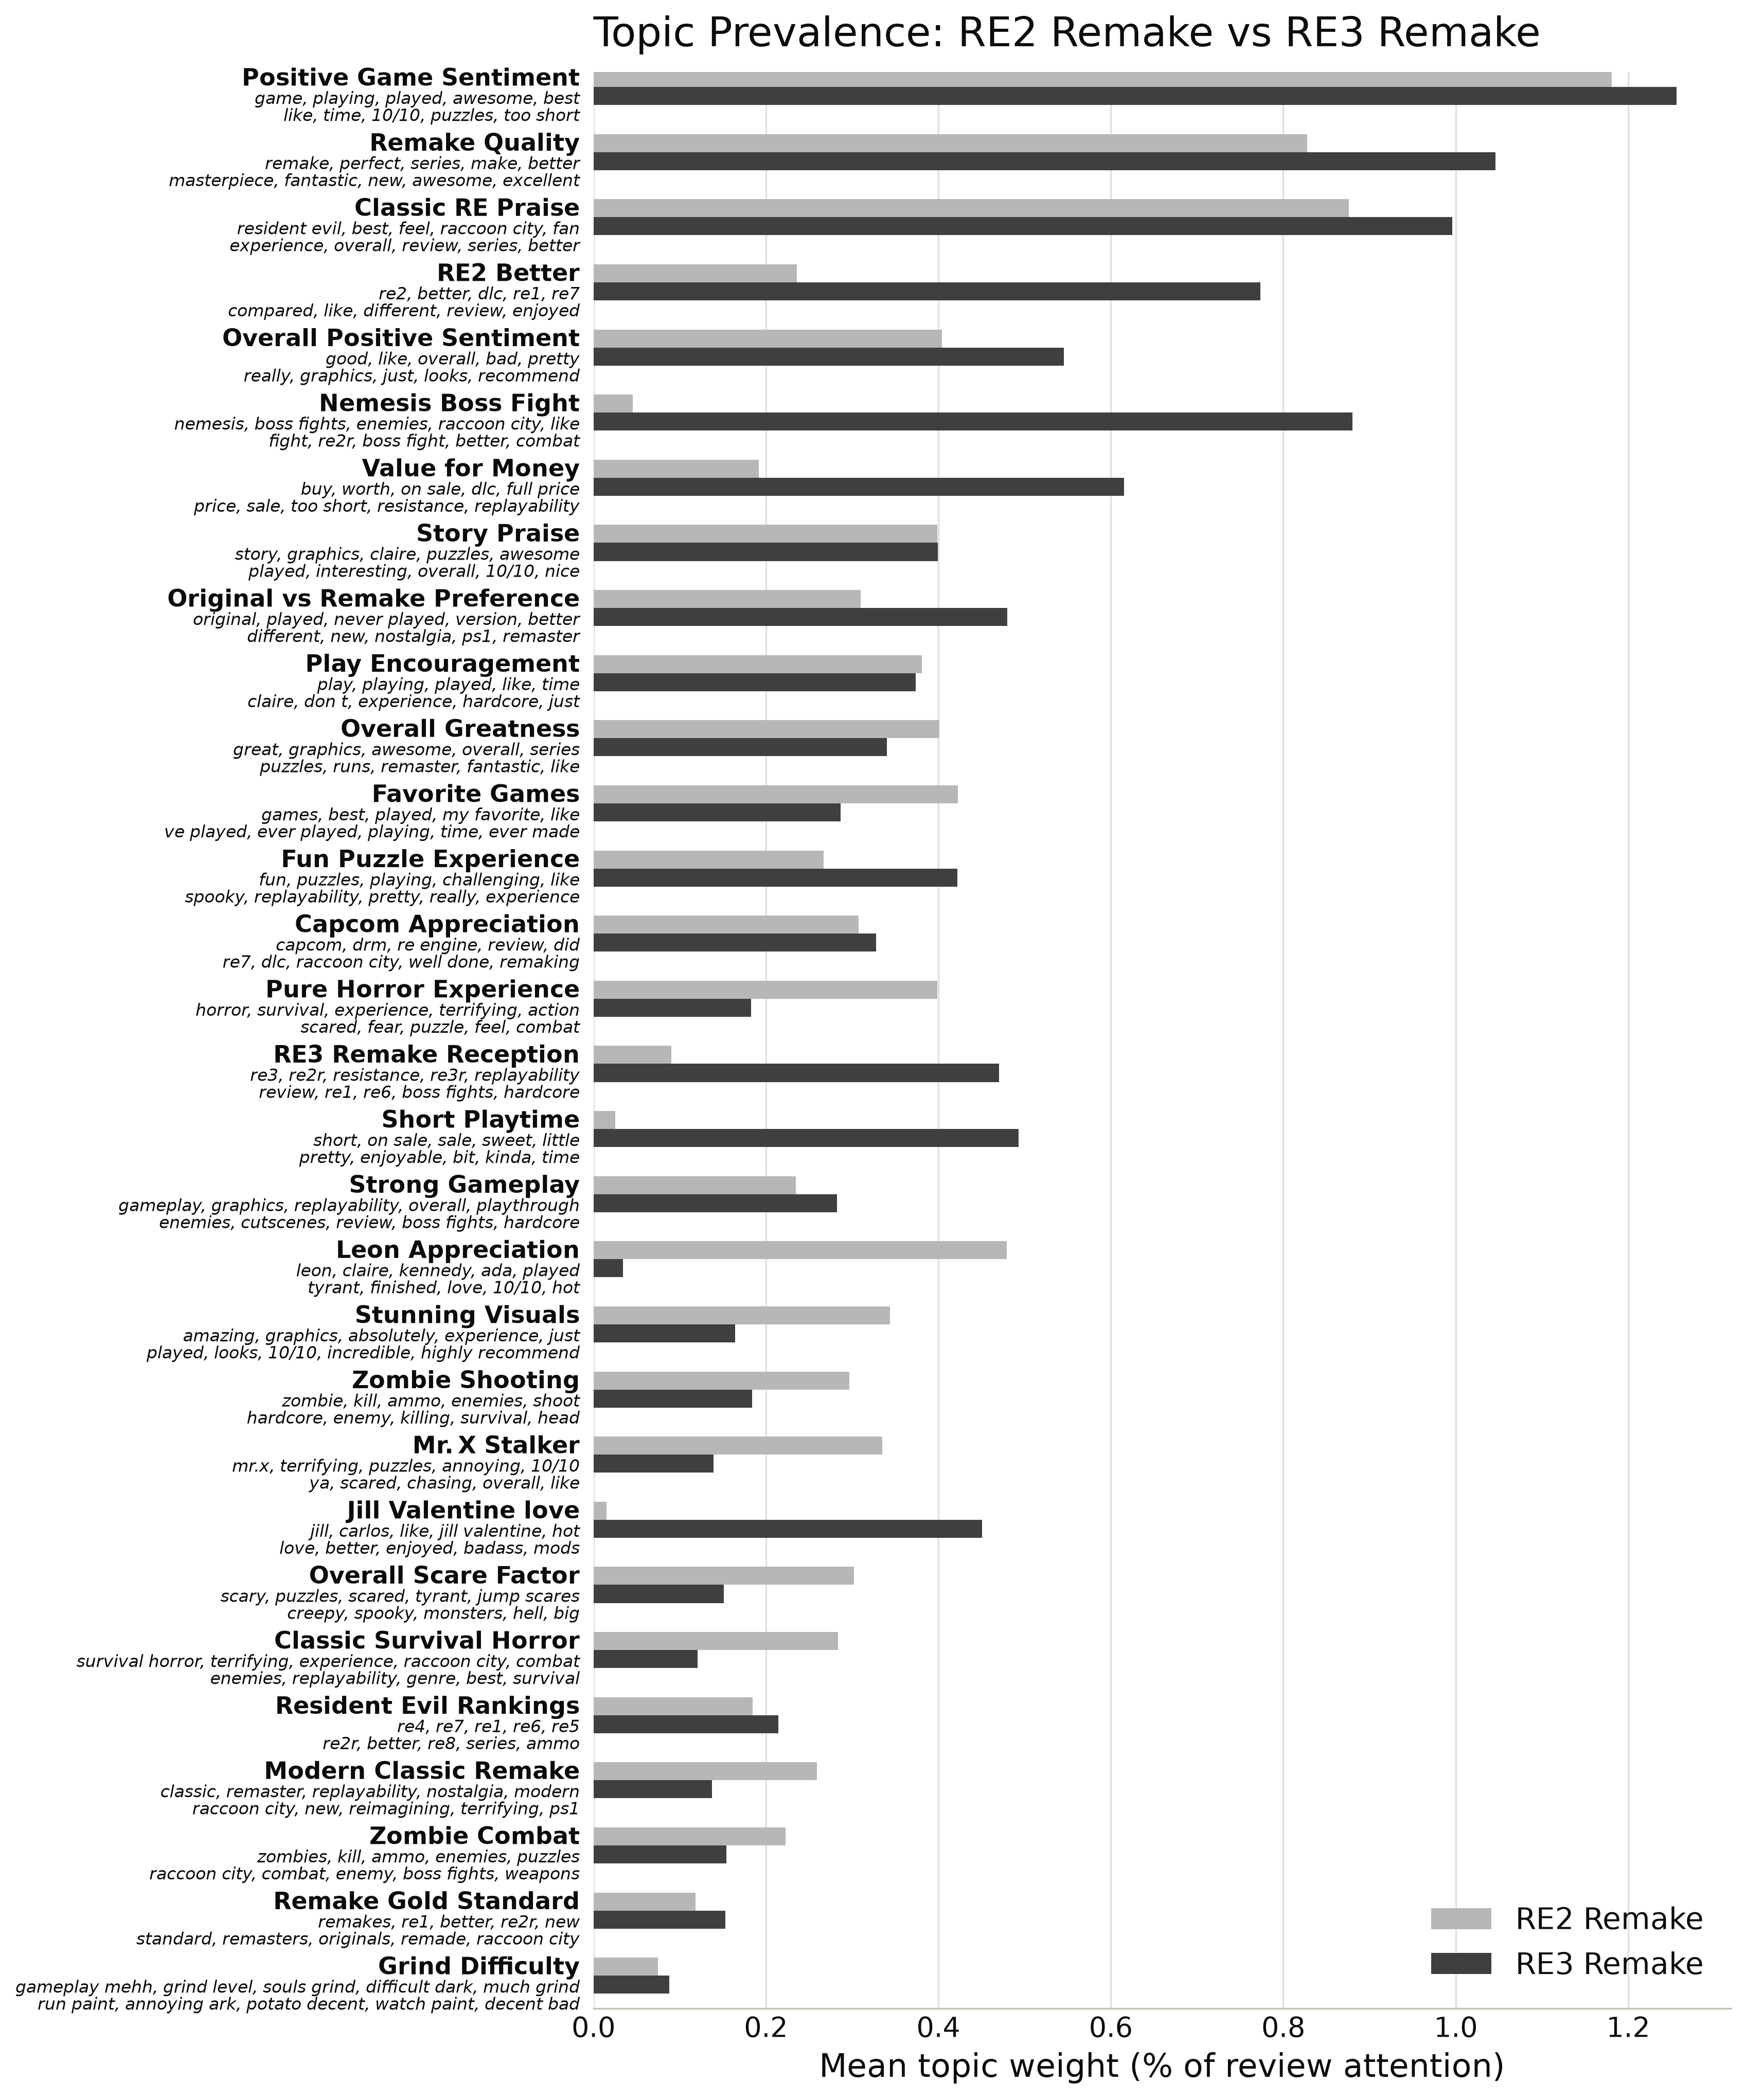

In [30]:
# Top keywords per topic, loaded from results/topic_labels.csv (topic_names
# and keywords_per_topic are index-aligned). Shows all of them, wrapped onto a
# second line past 5 rather than truncated.
topic_keyword_map = dict(zip(topic_names, keywords_per_topic))
KEYWORDS_PER_ROW = 5


def chunk_list(lst, size):
    return [lst[i : i + size] for i in range(0, len(lst), size)]


# Underscore-joined keywords read as spaced-out phrases for display, so "jill_valentine" ->
# "jill valentine". Except for a few special cases like "10_10" which is a review score ("10/10"), 
# not two separate words, and "mr_x" reads better as "mr.x"
KEYWORD_DISPLAY_OVERRIDES = {"10_10": "10/10", "mr_x": "mr.x"}


def format_keyword(kw):
    return KEYWORD_DISPLAY_OVERRIDES.get(kw, kw.replace("_", " "))

plot_df = (per_game_topic_prevalence.T * 100)  # topics as rows, % of review attention
plot_df["total"] = plot_df["re2r"] + plot_df["re3r"]
plot_df = plot_df.sort_values("total", ascending=False)  # biggest first -> top after invert

ROW_HEIGHT = 1.30
LINE_SPACING = 0.34
fig, ax = plt.subplots(figsize=(11, 0.45 * len(plot_df) + 0.6), dpi=300)

y = np.arange(len(plot_df)) * ROW_HEIGHT
bar_height = 0.36

# RE2R and RE3R bars are drawn separately, offset vertically by half the bar height, so they don't overlap.
ax.barh(y - bar_height / 2, plot_df["re2r"], height=bar_height, color=COLOR_RE2R, label="RE2 Remake", zorder=3)
ax.barh(y + bar_height / 2, plot_df["re3r"], height=bar_height, color=COLOR_RE3R, label="RE3 Remake", zorder=3)

# Multi-line label per row, placed outside the axes instead of using the
# default single-style tick labels. Bold topic name on top, keyword line(s) underneath
ax.set_yticks(y)
ax.set_yticklabels([])
ax.tick_params(axis="y", length=0)
for yi, topic_name in zip(y, plot_df.index):
    formatted_keywords = [format_keyword(k) for k in topic_keyword_map.get(topic_name, [])]
    keyword_lines = [", ".join(chunk) for chunk in chunk_list(formatted_keywords, KEYWORDS_PER_ROW)]
    ax.text(-0.012, yi - 0.15, topic_name, transform=ax.get_yaxis_transform(),
            ha="right", va="center", fontsize=11, color=INK_PRIMARY, fontweight="bold")
    for li, line in enumerate(keyword_lines):
        ax.text(-0.012, yi + 0.25 + li * LINE_SPACING, line, transform=ax.get_yaxis_transform(),
                ha="right", va="center", fontsize=8, color=INK_PRIMARY, style="italic")

ax.invert_yaxis()
ax.set_ylim(y[-1] + 0.65, y[0] - 0.3)

ax.set_xlabel("Mean topic weight (% of review attention)", color=INK_PRIMARY, fontsize=15)
ax.set_title("Topic Prevalence: RE2 Remake vs RE3 Remake", color=INK_PRIMARY, fontsize=19, loc="left", pad=12)

ax.xaxis.grid(True, color=GRIDLINE, linewidth=0.8, zorder=0)
ax.set_axisbelow(True)
for spine in ["top", "right", "left"]:
    ax.spines[spine].set_visible(False)
ax.spines["bottom"].set_color(BASELINE)
ax.tick_params(axis="x", colors=INK_PRIMARY, length=0, labelsize=13)

legend = ax.legend(loc="lower right", frameon=False, fontsize=14)
for text in legend.get_texts():
    text.set_color(INK_PRIMARY)

plt.subplots_adjust(left=0.30, right=0.97, top=0.95, bottom=0.06)
plt.savefig(VIZ_DIR / "topic_prevalence_by_game.png", bbox_inches="tight")
plt.show()

## Verifying write-up claims against the topic model

In [ ]:
RESULTS_DIR = Path("../results")

TOPIC_COLUMNS = [
    "Positive Game Sentiment", "Classic RE Praise", "Remake Quality", "RE2 Better",
    "Fun Puzzle Experience", "Classic Survival Horror", "Nemesis Boss Fight",
    "Overall Positive Sentiment", "Favorite Games", "Capcom Appreciation",
    "RE3 Remake Reception", "Strong Gameplay", "Zombie Combat", "Leon Appreciation",
    "Pure Horror Experience", "Original vs Remake Preference", "Overall Scare Factor",
    "Overall Greatness", "Stunning Visuals", "Mr.\u202fX Stalker", "Jill Valentine love",
    "Play Encouragement", "Zombie Shooting", "Remake Gold Standard", "Short Playtime",
    "Story Praise", "Resident Evil Rankings", "Modern Classic Remake", "Grind Difficulty",
    "Value for Money",
]

# Topic groupings used in the write-up. Character and fear groupings share a
# couple of topics on purpose (e.g. Mr. X Stalker is legitimately both a
# named-enemy topic and a fear topic)
TOPIC_GROUPS = {
    "character_topics": [
        "Leon Appreciation", "Jill Valentine love", "Play Encouragement", "Story Praise",
        "Nemesis Boss Fight", "Overall Scare Factor", "Mr.\u202fX Stalker",
    ],
    "gameplay_topics": [
        "Zombie Combat", "Zombie Shooting", "Fun Puzzle Experience", "Strong Gameplay",
    ],
    "fear_topics": [
        "Pure Horror Experience", "Overall Scare Factor", "Mr.\u202fX Stalker",
        "Classic Survival Horror",
    ],
}

# Compute topic-group prevalence
reviews_topic_scores = pd.read_csv(RESULTS_DIR / "reviews_with_topic_scores.csv", usecols=["game"] + TOPIC_COLUMNS)
total_by_game = reviews_topic_scores.groupby("game")[TOPIC_COLUMNS].sum()
grand_total_by_game = total_by_game.sum(axis=1)

rows = []
for group_name, topics in TOPIC_GROUPS.items():
    pct_of_weight = total_by_game[topics].sum(axis=1) / grand_total_by_game * 100
    for game in ["re2r", "re3r"]:
        rows.append({
            "topic_group": group_name,
            "game": game,
            "pct_of_topic_weight": pct_of_weight[game],
        })

topic_group_pct_df = pd.DataFrame(rows)
display(topic_group_pct_df)

# "Jill sandwich" mentions
# How often reviews mention "Jill sandwich" by game
jill_cols = ["game", "review"] + TOPIC_COLUMNS
reviews_jill = pd.read_csv(RESULTS_DIR / "reviews_with_topic_scores.csv", usecols=jill_cols)
reviews_jill["mentions_jill_sandwich"] = reviews_jill["review"].str.contains(
    r"jill[\s_-]*sandwich", case=False, na=False, regex=True
)

n_reviews_by_game = reviews_jill.groupby("game").size()
n_mentions_by_game = reviews_jill.groupby("game")["mentions_jill_sandwich"].sum()
pct_mentions_by_game = n_mentions_by_game / n_reviews_by_game * 100

# Rank the topics for each review, then create boolean columns for whether "Jill Valentine love" 
# is the top topic or among the top 3 topics.
topic_ranks = reviews_jill[TOPIC_COLUMNS].rank(axis=1, ascending=False, method="min")
reviews_jill["jill_topic_rank"] = topic_ranks["Jill Valentine love"]
reviews_jill["jill_is_top_topic"] = reviews_jill["jill_topic_rank"] == 1
reviews_jill["jill_is_top3_topic"] = reviews_jill["jill_topic_rank"] <= 3

jill_mentioning = reviews_jill[reviews_jill["mentions_jill_sandwich"]]
pct_mentioning_top1 = jill_mentioning.groupby("game")["jill_is_top_topic"].mean() * 100
pct_mentioning_top3 = jill_mentioning.groupby("game")["jill_is_top3_topic"].mean() * 100

# Same rates among ALL reviews (not just the mentioning ones), for comparison
pct_all_top1 = reviews_jill.groupby("game")["jill_is_top_topic"].mean() * 100
pct_all_top3 = reviews_jill.groupby("game")["jill_is_top3_topic"].mean() * 100

# Create a summary DataFrame for the Jill sandwich analysis
    # n_reviews: total number of reviews per game
    # n_mentions: number of reviews mentioning "Jill sandwich" per game
    # pct_mentions: percentage of reviews mentioning "Jill sandwich" per game
    # pct_top1_mentioning: percentage of mentioning reviews where "Jill Valentine love" is the top topic
    # pct_top1_baseline: percentage of all reviews where "Jill Valentine love" is the top topic
    # pct_top3_mentioning: percentage of mentioning reviews where "Jill Valentine love" is among the top 3 topics
    # pct_top3_baseline: percentage of all reviews where "Jill Valentine love" is among the top 3 topics   
jill_sandwich_df = pd.DataFrame({
    "n_reviews": n_reviews_by_game,
    "n_mentions": n_mentions_by_game,
    "pct_mentions": pct_mentions_by_game,
    "pct_top1_mentioning": pct_mentioning_top1,
    "pct_top1_baseline": pct_all_top1,
    "pct_top3_mentioning": pct_mentioning_top3,
    "pct_top3_baseline": pct_all_top3,
})
jill_sandwich_df

,topic_group,game,pct_of_topic_weight
0,character_topics,re2r,19.734895
1,character_topics,re3r,19.967807
2,gameplay_topics,re2r,10.301166
3,gameplay_topics,re3r,8.576075
4,fear_topics,re2r,13.306366
5,fear_topics,re3r,4.884536


,n_reviews,n_mentions,pct_mentions,pct_top1_mentioning,pct_top1_baseline,pct_top3_mentioning,pct_top3_baseline
game,,,,,,,
re2r,80118,28,0.034948,39.285714,20.362465,50.000000,37.221349
re3r,44657,105,0.235126,58.095238,20.498466,71.428571,34.932933


## Permutation Tests of Means (Not Used in Paper)

In [36]:
# Permutation test on the difference in means. Attaches significance directly to the same
# re2r_mean/re3r_mean numbers already being reported.
N_PERMUTATIONS = 10_000
rng = np.random.default_rng(0)

dtm = review_topic_scores[topic_names].to_numpy()
is_re2r = (review_topic_scores["game"] == "re2r").to_numpy()

# mean_diff = re3r_mean - re2r_mean (positive = more prevalent in RE3r)
observed_diff = dtm[~is_re2r].mean(axis=0) - dtm[is_re2r].mean(axis=0)

idx = np.arange(len(dtm))
null_diffs = np.empty((N_PERMUTATIONS, dtm.shape[1]))
for i in range(N_PERMUTATIONS):
    rng.shuffle(idx)
    shuffled_mask = is_re2r[idx]
    null_diffs[i] = dtm[~shuffled_mask].mean(axis=0) - dtm[shuffled_mask].mean(axis=0)

p_values = (np.abs(null_diffs) >= np.abs(observed_diff)).mean(axis=0)
p_values = np.maximum(p_values, 1 / (N_PERMUTATIONS + 1))

re2r_mean = dtm[is_re2r].mean(axis=0)
re3r_mean = dtm[~is_re2r].mean(axis=0)

topic_diff = pd.DataFrame({
    "topic": topic_names,
    "re2r_mean": re2r_mean,
    "re3r_mean": re3r_mean,
    "mean_diff": observed_diff,
    "p_value": p_values,
})
# Benjamini-Hochberg FDR correction across all 30 topics tested at once.
topic_diff["significant_fdr"] = multipletests(topic_diff["p_value"], method="fdr_bh")[0]

#   mean_diff_pp   — the same gap expressed in percentage points
#   leans_toward   — which game the topic is more prevalent in
#   prevalence_ratio — how many times more prevalent the topic is in the
#                    leaning game (always >= 1)
topic_diff["mean_diff_pp"] = topic_diff["mean_diff"] * 100
topic_diff["leans_toward"] = np.where(topic_diff["mean_diff"] >= 0, "RE3r", "RE2r")
topic_diff["prevalence_ratio"] = np.where(
    topic_diff["mean_diff"] >= 0,
    topic_diff["re3r_mean"] / topic_diff["re2r_mean"],
    topic_diff["re2r_mean"] / topic_diff["re3r_mean"],
)

topic_diff.sort_values("mean_diff_pp", key=abs, ascending=False)

,topic,re2r_mean,re3r_mean,mean_diff,p_value,significant_fdr,mean_diff_pp,leans_toward,prevalence_ratio
6,Nemesis Boss Fight,0.000457,0.008800,0.008343,0.0001,True,0.834304,RE3r,19.250480
3,RE2 Better,0.002360,0.007737,0.005377,0.0001,True,0.537705,RE3r,3.278322
24,Short Playtime,0.000254,0.004931,0.004678,0.0001,True,0.467769,RE3r,19.443559
13,Leon Appreciation,0.004791,0.000345,-0.004446,0.0001,True,-0.444634,RE2r,13.892016
20,Jill Valentine love,0.000154,0.004506,0.004352,0.0001,True,0.435182,RE3r,29.239641
29,Value for Money,0.001918,0.006151,0.004233,0.0001,True,0.423320,RE3r,3.207176
10,RE3 Remake Reception,0.000904,0.004704,0.003800,0.0001,True,0.380012,RE3r,5.201931
2,Remake Quality,0.008275,0.010462,0.002188,0.0001,True,0.218758,RE3r,1.264370
14,Pure Horror Experience,0.003985,0.001827,-0.002159,0.0001,True,-0.215857,RE2r,2.181797
19,Mr. X Stalker,0.003350,0.001391,-0.001958,0.0001,True,-0.195847,RE2r,2.407563


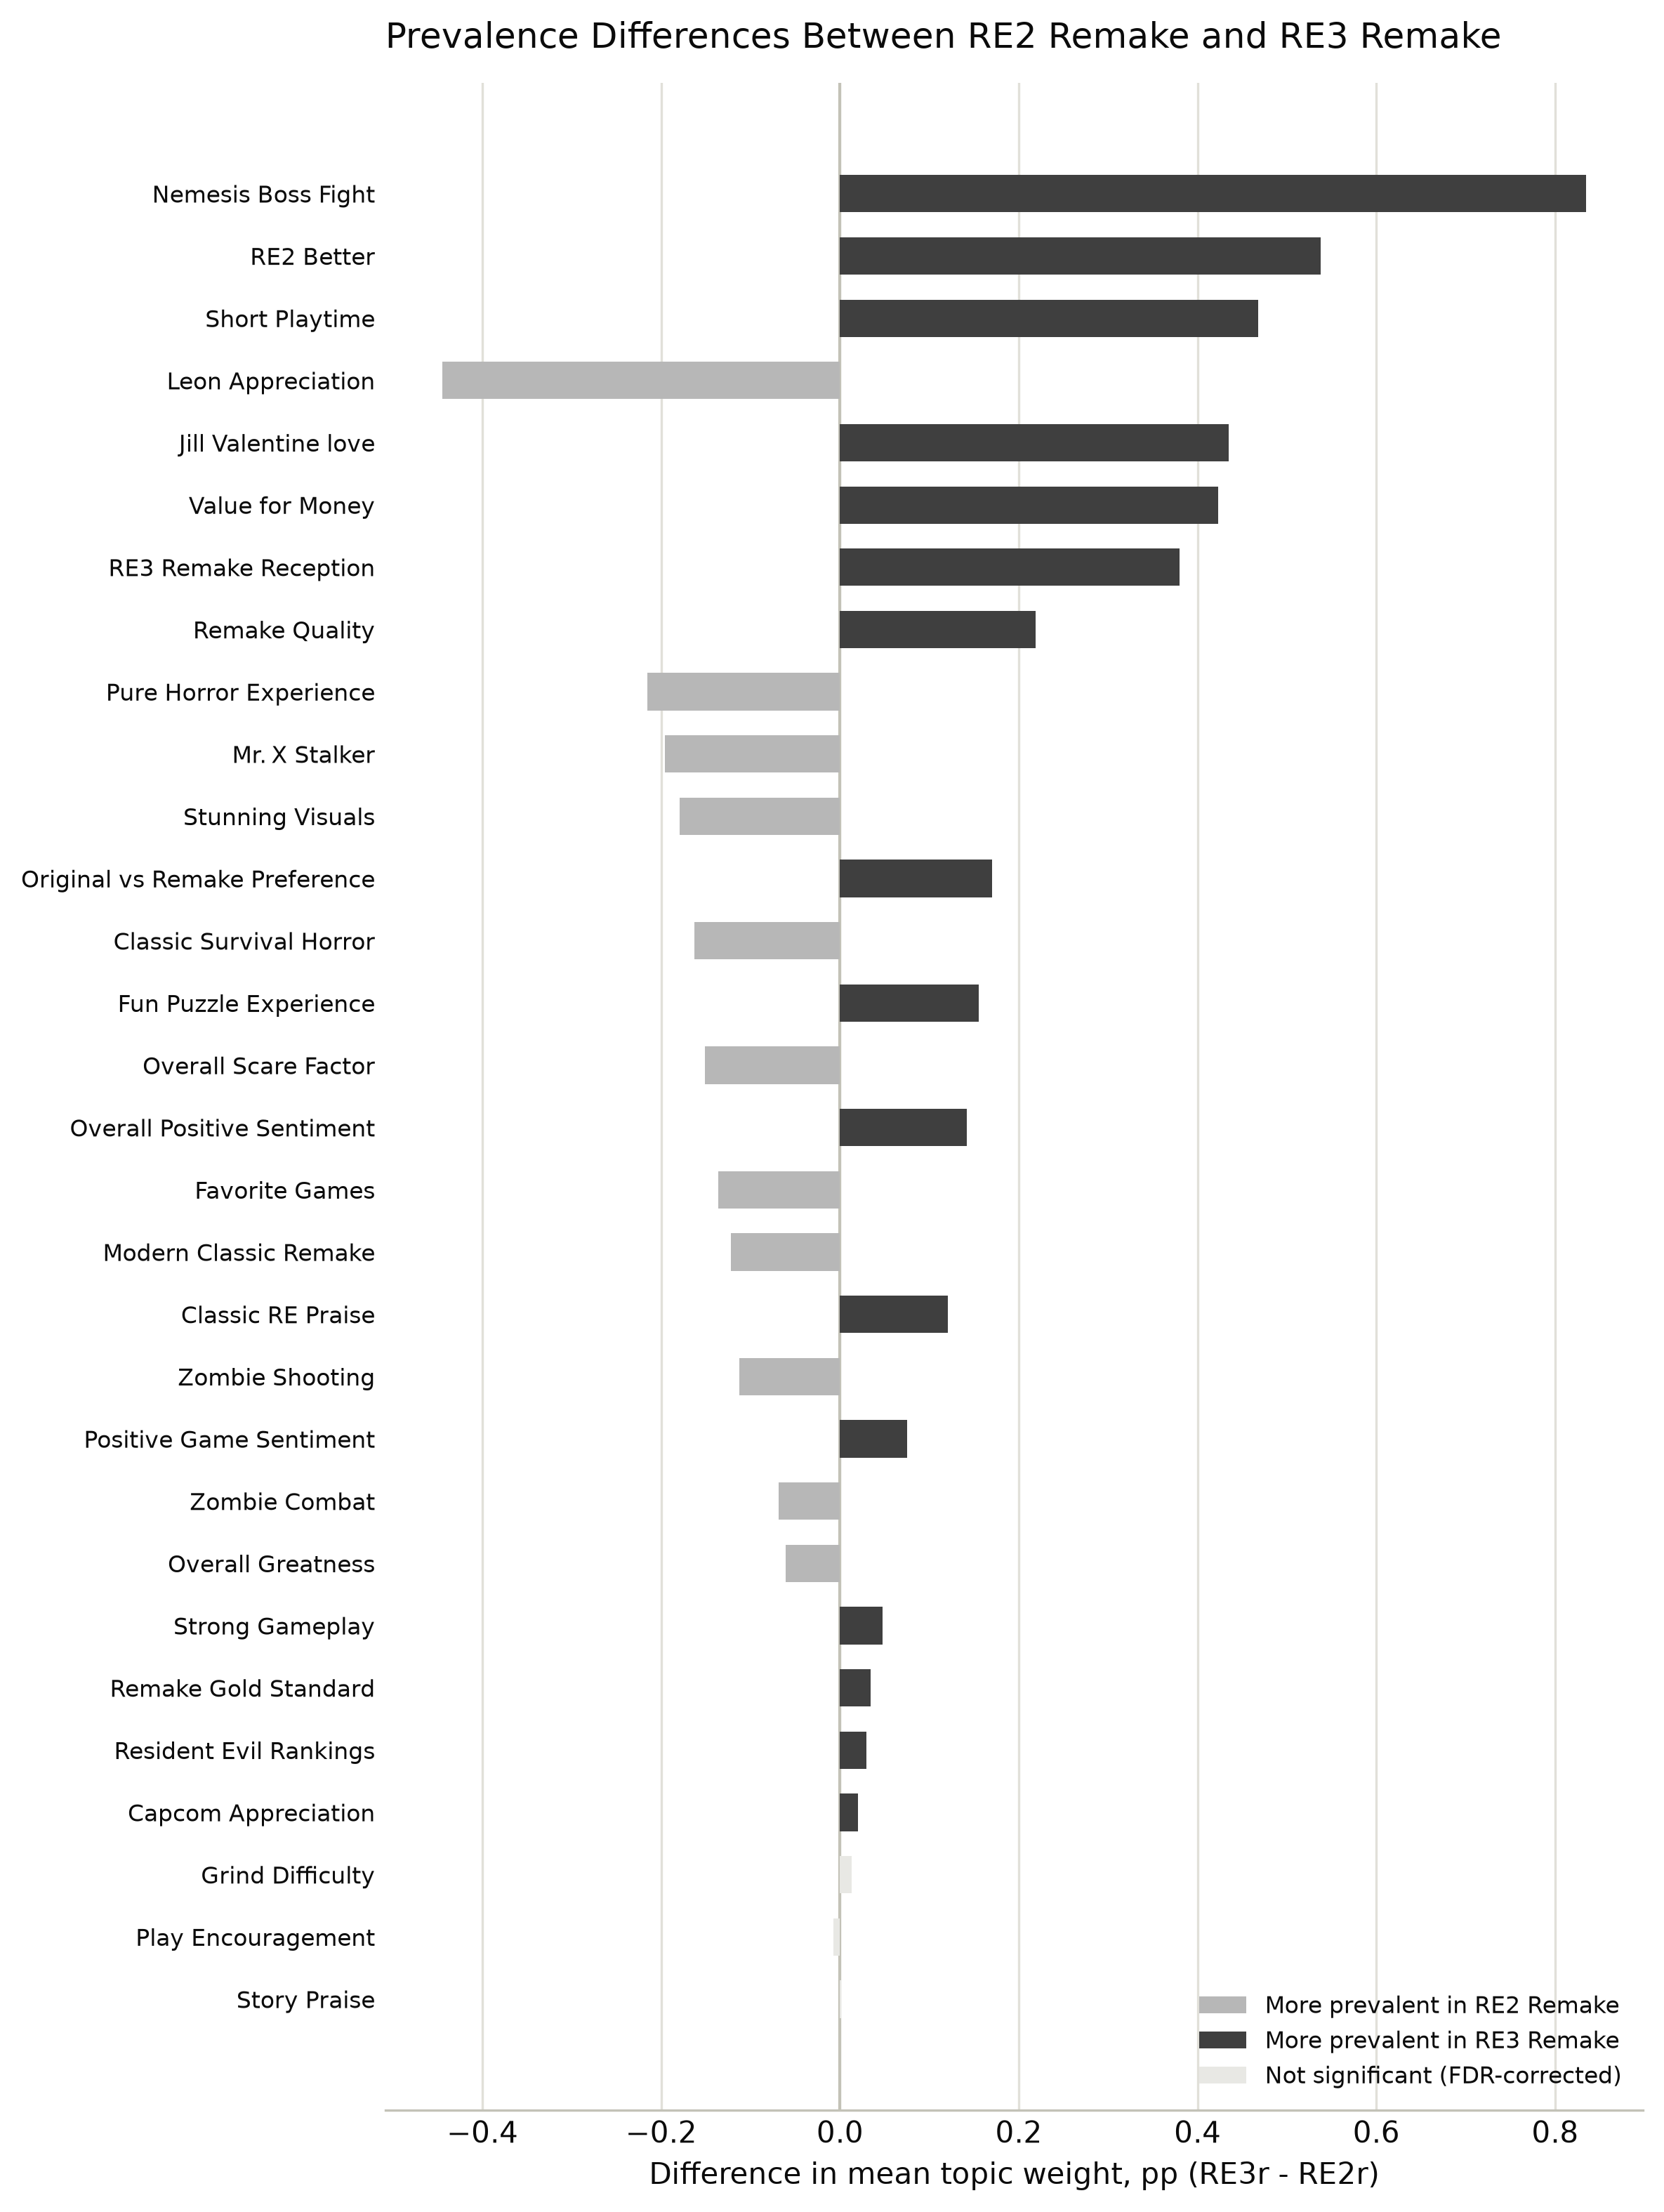

In [37]:
COLOR_NOT_SIG = "#e8e8e4"

plot_df = topic_diff.copy()
plot_df["diff_pct"] = plot_df["mean_diff"] * 100
plot_df = plot_df.reindex(plot_df["diff_pct"].abs().sort_values(ascending=True).index)

colors = np.where(
    plot_df["significant_fdr"],
    np.where(plot_df["diff_pct"] >= 0, COLOR_RE3R, COLOR_RE2R),
    COLOR_NOT_SIG,
)

fig, ax = plt.subplots(figsize=(8, 0.32 * len(plot_df) + 1), dpi=300)
y = np.arange(len(plot_df))

ax.barh(y, plot_df["diff_pct"], height=0.6, color=colors, zorder=3)

ax.axvline(0, color=BASELINE, linewidth=1, zorder=2)
ax.set_yticks(y)
ax.set_yticklabels(plot_df["topic"], fontsize=8, color=INK_PRIMARY)

ax.set_xlabel("Difference in mean topic weight, pp (RE3r - RE2r)", color=INK_PRIMARY, fontsize=10)
ax.set_title("Prevalence Differences Between RE2 Remake and RE3 Remake", color=INK_PRIMARY, fontsize=12, loc="left", pad=12)

ax.xaxis.grid(True, color=GRIDLINE, linewidth=0.8, zorder=0)
ax.set_axisbelow(True)
for spine in ["top", "right", "left"]:
    ax.spines[spine].set_visible(False)
ax.spines["bottom"].set_color(BASELINE)
ax.tick_params(axis="both", colors=INK_PRIMARY, length=0)

legend_handles = [
    Patch(facecolor=COLOR_RE2R, label="More prevalent in RE2 Remake"),
    Patch(facecolor=COLOR_RE3R, label="More prevalent in RE3 Remake"),
    Patch(facecolor=COLOR_NOT_SIG, label="Not significant (FDR-corrected)"),
]
legend = ax.legend(handles=legend_handles, loc="lower right", frameon=False, fontsize=8)
for text in legend.get_texts():
    text.set_color(INK_PRIMARY)

plt.tight_layout()
plt.savefig(VIZ_DIR / "topic_diff_diverging.png", bbox_inches="tight")
plt.show()